# Laboratorio 8
CC3094 Security Data Science  
Sección 10  
Erick Stiv Junior Guerra Muñoz - 21781  
  
Repositorio de GitHub: https://github.com/erickguerra22/SDS_Lab8.git

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os
import matplotlib.image as mpimg
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

1. En el preprocesamiento debe mostrar cuantos ejemplares hay por cada familia. En base a
estos datos debe determinar si considera pertinente prescindir de ejemplares que tengan
pocas observaciones.

Familias originales: 25, Familias filtradas: 14
Adialer.C: 122 imágenes
Agent.FYI: 116 imágenes
Allaple.A: 2949 imágenes
Allaple.L: 1591 imágenes
Alueron.gen!J: 198 imágenes
Autorun.K: 106 imágenes
C2LOP.gen!g: 200 imágenes
C2LOP.P: 146 imágenes
Dialplatform.B: 177 imágenes
Dontovo.A: 162 imágenes
Fakerean: 381 imágenes
Instantaccess: 431 imágenes
Lolyda.AA1: 213 imágenes
Lolyda.AA2: 184 imágenes
Lolyda.AA3: 123 imágenes
Lolyda.AT: 159 imágenes
Malex.gen!J: 136 imágenes
Obfuscator.AD: 142 imágenes
Rbot!gen: 158 imágenes
Skintrim.N: 80 imágenes
Swizzor.gen!E: 128 imágenes
Swizzor.gen!I: 132 imágenes
VB.AT: 408 imágenes
Wintrim.BX: 97 imágenes
Yuner.A: 800 imágenes


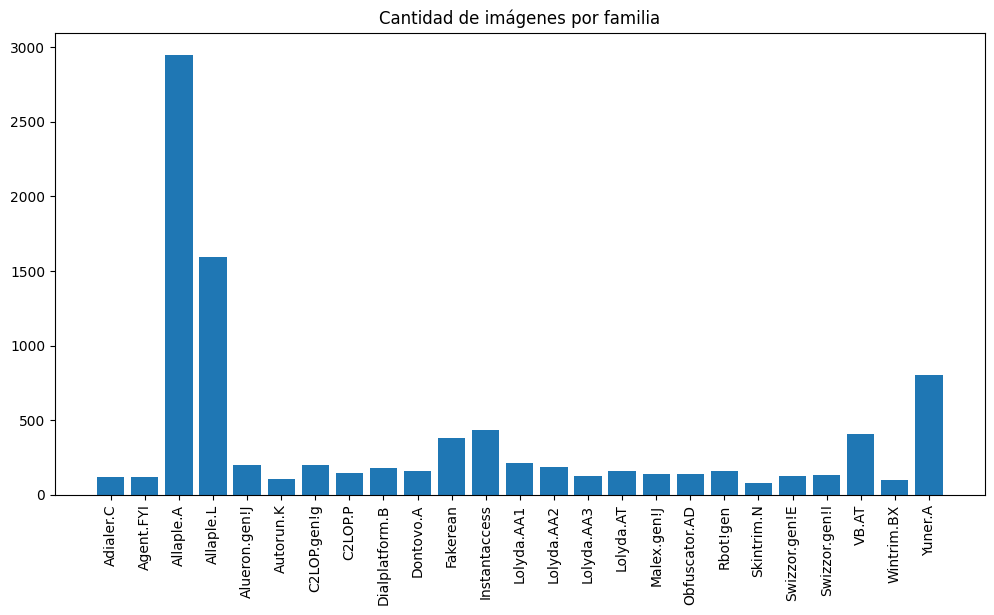

In [ ]:
dataset_path = "malimg_paper_dataset_imgs"
families = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

family_counts = {family: len(os.listdir(os.path.join(dataset_path, family))) for family in families}

# Se pescinde de las familias con menos de 150 imágenes
filtered_families = [family for family in families if family_counts[family] >= 150]
print(f"Familias originales: {len(families)}, Familias filtradas: {len(filtered_families)}")

for family, count in family_counts.items():
    print(f"{family}: {count} imágenes")

plt.figure(figsize=(12,6))
plt.bar(family_counts.keys(), family_counts.values())
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por familia")
plt.show()


2. Plotee algunas imágenes de los ejemplos de malware.

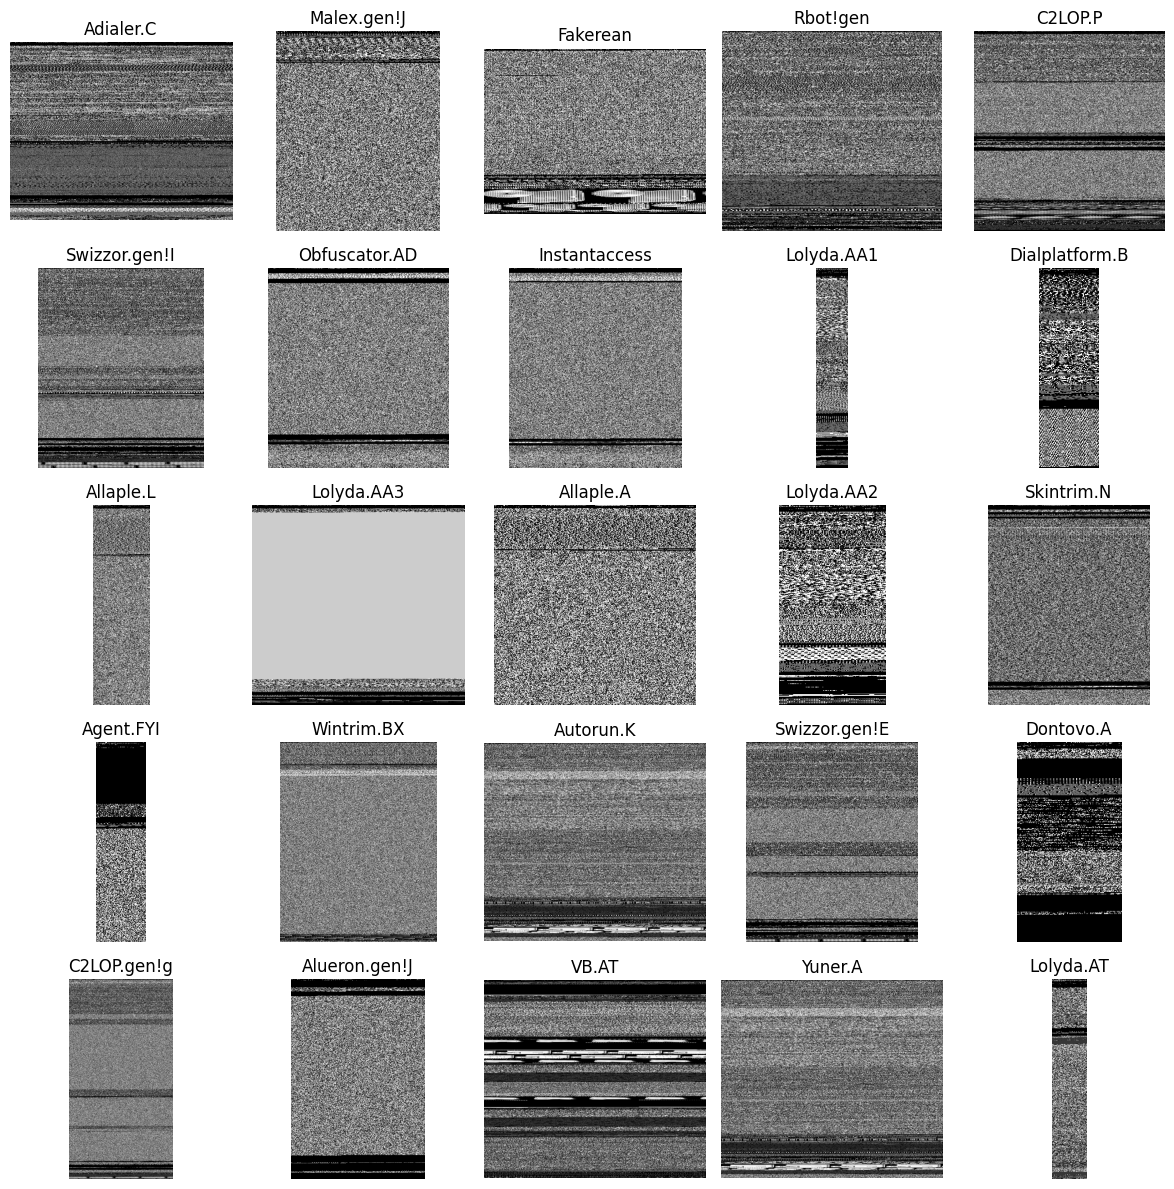

In [17]:
plt.figure(figsize=(12, 12))

for i, family in enumerate(random.sample(families, 25)):
    img_path = os.path.join(dataset_path, family)
    img_file = random.choice(os.listdir(img_path))
    img = mpimg.imread(os.path.join(img_path, img_file))
    plt.subplot(5, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(family)
    plt.axis('off')

plt.tight_layout()
plt.show()

3. Utilizando Keras y Tensorflow construya una red neuronal con las capas, funciones de
activación y el optimizador que considere conveniente.

In [ ]:
img_size = (64, 64)

datagen = ImageDataGenerator(
    validation_split=0.3,
    rescale=1./255
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


Found 6549 images belonging to 25 classes.
Found 2790 images belonging to 25 classes.


C:\Users\erick\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Muestre el resumen del modelo

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,801 (6.21 MB)

 Trainable params: 1,627,801 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

6. Entrene el modelo con el número de épocas que considere conveniente.

In [20]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10


C:\Users\erick\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 37s 173ms/step - accuracy: 0.4438 - loss: 1.9367 - val_accuracy: 0.8878 - val_loss: 0.5330
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.8289 - loss: 0.5815 - val_accuracy: 0.9147 - val_loss: 0.2767
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 33s 159ms/step - accuracy: 0.8980 - loss: 0.3251 - val_accuracy: 0.9362 - val_loss: 0.2177
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 33s 160ms/step - accuracy: 0.9241 - loss: 0.2416 - val_accuracy: 0.9448 - val_loss: 0.1791
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 154ms/step - accuracy: 0.9374 - loss: 0.1888 - val_accuracy: 0.9498 - val_loss: 0.1923
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 35s 172ms/step - accuracy: 0.9471 - loss: 0.1648 - val_accuracy: 0.9530 - val_loss: 0.1797
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 164ms/step - accuracy: 0.9502 - loss: 0.1502 - val_accuracy: 0.9556 - val_loss: 0.1855
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - accuracy: 0.9592 - loss: 0.1258 - val

7. Muestre las métricas de su modelo.

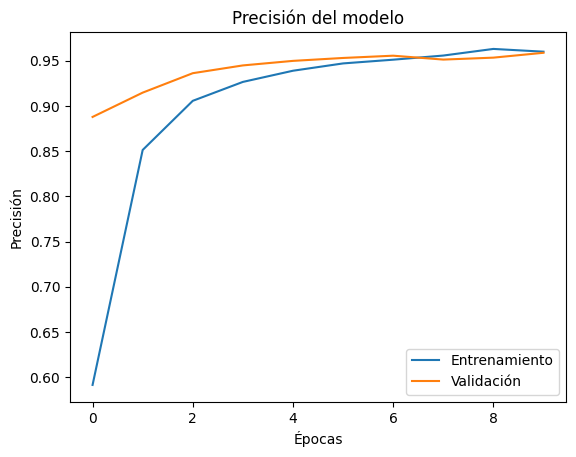

In [21]:
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

8. Evalúe el modelo con el dataset de pruebas y muestre las métricas obtenidas. Discuta los
resultados obtenidos.

88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9826 - loss: 0.0657
Loss: 0.1773
Accuracy: 0.9588
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step

Reporte de Clasificación:
                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        36
     Agent.FYI       0.97      1.00      0.99        34
     Allaple.A       0.99      1.00      1.00       884
     Allaple.L       1.00      1.00      1.00       477
 Alueron.gen!J       0.98      1.00      0.99        59
     Autorun.K       0.00      0.00      0.00        31
       C2LOP.P       0.62      0.74      0.67        43
   C2LOP.gen!g       0.76      0.95      0.84        60
Dialplatform.B       1.00      0.96      0.98        53
     Dontovo.A       0.98      1.00      0.99        48
      Fakerean       1.00      0.96      0.98       114
 Instantaccess       0.99      1.00      1.00       129
    Lolyda.AA1       0.97      1.00      0.98        63
    Lolyda.AA2       1.00      0.95      0.9

c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1200x1000 with 0 Axes>

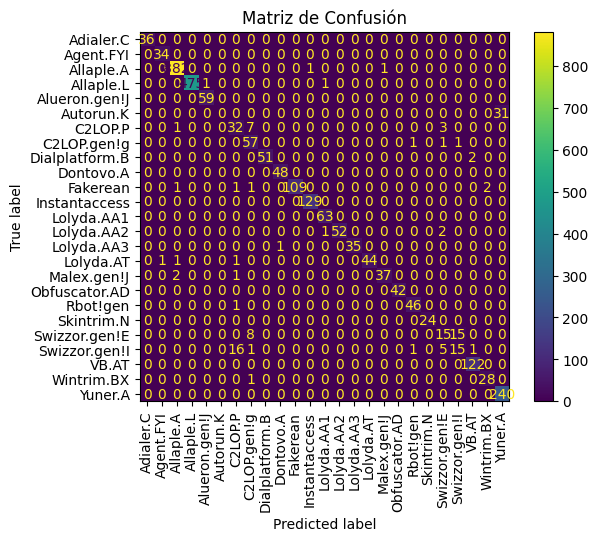

In [22]:
loss, accuracy = model.evaluate(val_generator)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(xticks_rotation=90)
plt.title("Matriz de Confusión")
plt.show()

### Discusión de resultados

La evaluación del modelo de clasificación de malware un rendimiento general sólido con una precisión del 95.88% en el conjunto de pruebas, evidenciando una buena capacidad para identificar correctamente la mayoría de las clases de malware. La matriz de confusión revela que familias como Adialer.C, Allaple.A, Allaple.L e Instantaccess alcanzan métricas casi perfectas, con valores F1 cercanos o iguales a 1.0. Sin embargo, el modelo presenta deficiencias significativas en algunas clases específicas, siendo la más notable Autorun.K, donde falla completamente (0% en todas las métricas), y en la familia C2LOP, con precisiones de 62% para C2LOP.P y 76% para C2LOP.gen!g.

Estos resultados sugieren que, aunque el modelo funciona excepcionalmente bien para la mayoría de las familias de malware, existen problemas de clasificación para ciertas variantes, posiblemente debido al desbalance en las muestras de entrenamiento o bien, a la similitud entre características de algunas familias. La diferencia entre la precisión de entrenamiento (98.26%) y prueba (95.88%) indica un ligero sobreajuste, pero dentro de márgenes aceptables.